# Model Import, Export, and Artifact Bundles


**Purpose.** Follow a portable SSH model through JSON persistence, Hamiltonian construction, bundle export, external matrix import, and numerical round-trip validation.


**Lattice model.** The main example is an SSH `ModelSpec` with $H=\sum_n(t_1 a_n^\dagger b_n+t_2 b_n^\dagger a_{n+1}+h.c.)$. External matrix import stores an already-built Hamiltonian with basis, geometry, units, conventions, provenance, and optional physical records.


**Variables.** $N_c$ is set by `n_cells`; $t_1$ and $t_2$ are SSH hoppings; `model_path` is the JSON specification path; `bundle_paths` contains exported bundle artifacts; `metadata` supplies basis and provenance for external imports; `restored_result.matrix` is the reloaded Hamiltonian.


**Outputs.** The notebook verifies model and matrix round trips, writes bundles, imports an external matrix, and plots matrix magnitude or phase checks.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from quantum_lattice_models import (
    create_model_spec,
    export_hamiltonian_artifact,
    import_hamiltonian,
    load_hamiltonian,
    load_model,
    save_hamiltonian,
)
from quantum_lattice_models.plotting import plot_hamiltonian_matrix

repository_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
output_dir = repository_root / "results/notebooks/interchange"
output_dir.mkdir(parents=True, exist_ok=True)

In [2]:
model = create_model_spec(
    "ssh_model",
    parameters={"n_cells": 5, "t1": 0.4, "t2": 1.0, "periodic": False},
    units={"t1": "eV", "t2": "eV"},
    provenance={"notebook": "18_model_import_export_and_bundles"},
)
model_path = model.save(output_dir / "ssh.json")
restored_model = load_model(model_path)
bundle_paths = export_hamiltonian_artifact(
    restored_model.build_result(),
    output_dir / "ssh.bundle",
    artifact="bundle",
    format="npz",
)
restored_result = load_hamiltonian(output_dir / "ssh.bundle/matrix.npz")

print("Portable SSH bundle")
print(f"  model round trip: {restored_model == model}")
print(f"  matrix round trip: {np.allclose(restored_result.matrix, model.hamiltonian())}")
print(f"  files: {', '.join(path.name for path in bundle_paths)}")

Portable SSH bundle
  model round trip: True
  matrix round trip: True
  files: matrix.npz, model.json, metadata.json, lattice.json, manifest.json


In [3]:
external_matrix = np.array(
    [[0.2, -1.0, 0.0], [-1.0, 0.0, 0.35j], [0.0, -0.35j, -0.2]],
    dtype=complex,
)
external_path = output_dir / "external.npy"
np.save(external_path, external_matrix, allow_pickle=False)
external_metadata = {
    "basis": "single-particle site basis",
    "basis_dimension": 3,
    "lattice": {
        "n_sites": 3,
        "positions": [[0.0, 0.0], [1.0, 0.0], [0.5, 0.8]],
        "bonds": [],
        "site_labels": ["left", "right", "top"],
    },
    "local_degrees": [
        {"index": i, "site": i, "kind": "orbital", "local_dimension": 2, "label": label}
        for i, label in enumerate(("left", "right", "top"))
    ],
    "basis_mappings": [
        {"local_degree": i, "basis_index": i, "role": "single_particle_state"} for i in range(3)
    ],
    "units": {"energy": "eV"},
    "provenance": {"source": "notebook-generated external matrix"},
}
metadata_path = output_dir / "external-metadata.json"
metadata_path.write_text(json.dumps(external_metadata, indent=2, sort_keys=True) + "\n")
imported = import_hamiltonian(external_path, metadata_path=metadata_path)
portable_path = save_hamiltonian(imported, output_dir / "external-portable.npz")

print("External matrix import")
print(f"  portable file: {portable_path.relative_to(repository_root)}")
print(f"  basis: {imported.basis}")
print(f"  local degrees: {len(imported.model.local_degrees)}")
print(f"  matrix preserved: {np.allclose(imported.matrix, external_matrix)}")

External matrix import
  portable file: results/notebooks/interchange/external-portable.npz
  basis: single-particle site basis
  local degrees: 3
  matrix preserved: True


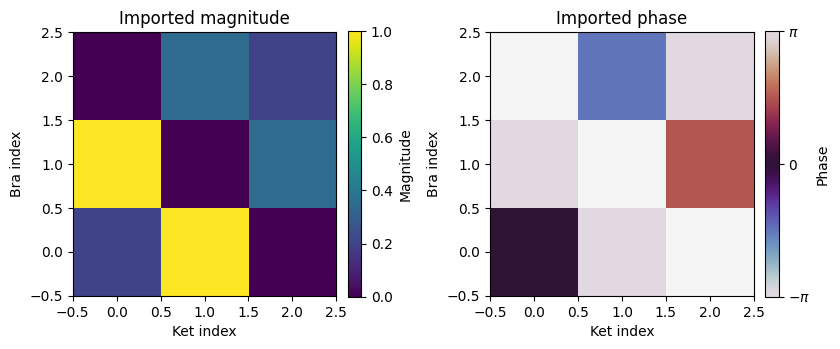

In [4]:
figure, axes = plt.subplots(1, 2, figsize=(8.5, 3.7))
plot_hamiltonian_matrix(imported.matrix, ax=axes[0], mode="magnitude")
plot_hamiltonian_matrix(imported.matrix, ax=axes[1], mode="phase")
axes[0].set_title("Imported magnitude")
axes[1].set_title("Imported phase")
figure.tight_layout()

The registered model remains reconstructable from `model.json`; the external model remains analyzable and portable through its persisted matrix file without pretending that an unavailable builder can reconstruct it.